# Customer Intelligence System
### Celebal Technologies | Week 3 Assignment

**Problem Statement:**  
HELP International has raised $10 million. The CEO must decide which countries need aid the most.  
Categorise countries using socio-economic & health factors, then suggest which the CEO should prioritise.

**Approach:** Classification → Ensemble Learning (Random Forest, XGBoost) → Clustering (K-Means, DBSCAN)

**Dataset:** Unsupervised Learning on Country Data — 167 countries × 9 features


## 1. Install Libraries

In [1]:
import subprocess, sys
packages = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "xgboost"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("All packages installed successfully.")

All packages installed successfully.


## 2. Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 4)
sns.set(style="whitegrid")
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, silhouette_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
print("All imports successful.")

All imports successful.


## 3. Load & Inspect Data

| Column | Description |
|---|---|
| `child_mort` | Child mortality per 1000 births |
| `exports` | Exports as % of GDP |
| `health` | Health spending as % of GDP |
| `imports` | Imports as % of GDP |
| `income` | Net income per person (USD) |
| `inflation` | Annual inflation rate (%) |
| `life_expec` | Life expectancy (years) |
| `total_fer` | Total fertility rate |
| `gdpp` | GDP per capita (USD) |


In [3]:
df = pd.read_csv("Country-data.csv")
df.columns = [c.strip().lower() for c in df.columns]
print("Shape:", df.shape)
df.head(10)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.0,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.0,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.0,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.0,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.0,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.0,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.0,2.95,1.51,1.15,1.80,2.41,3.88,7.49
gdpp,167.0,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


## 4. Data Cleaning

In [5]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
numeric_cols = [c for c in df.columns if c != "country"]
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
print("\nData is clean — no nulls or duplicates.")

Missing values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate rows: 0

Data is clean — no nulls or duplicates.


## 5. Exploratory Data Analysis (EDA)

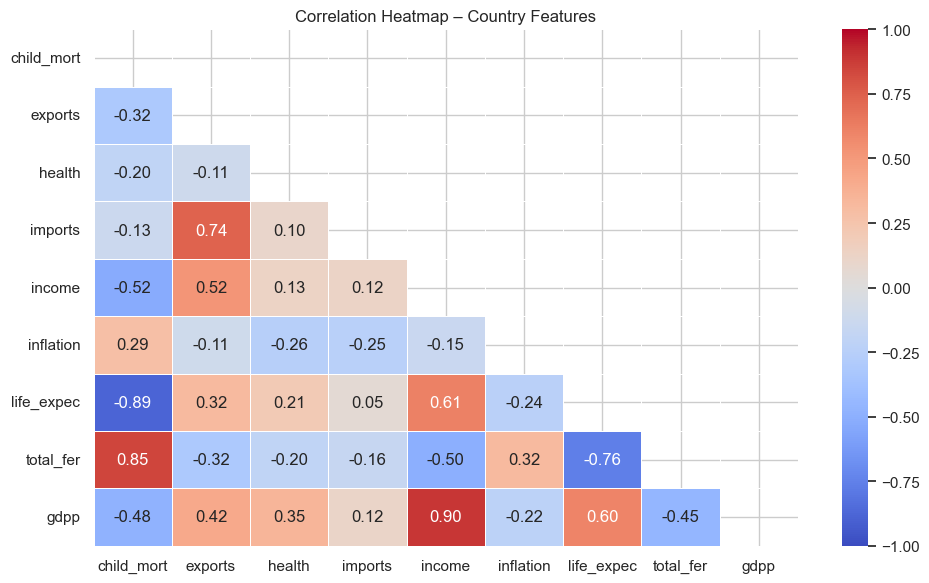

In [6]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.4, vmin=-1, vmax=1)
plt.title("Correlation Heatmap – Country Features")
plt.tight_layout()
plt.show()

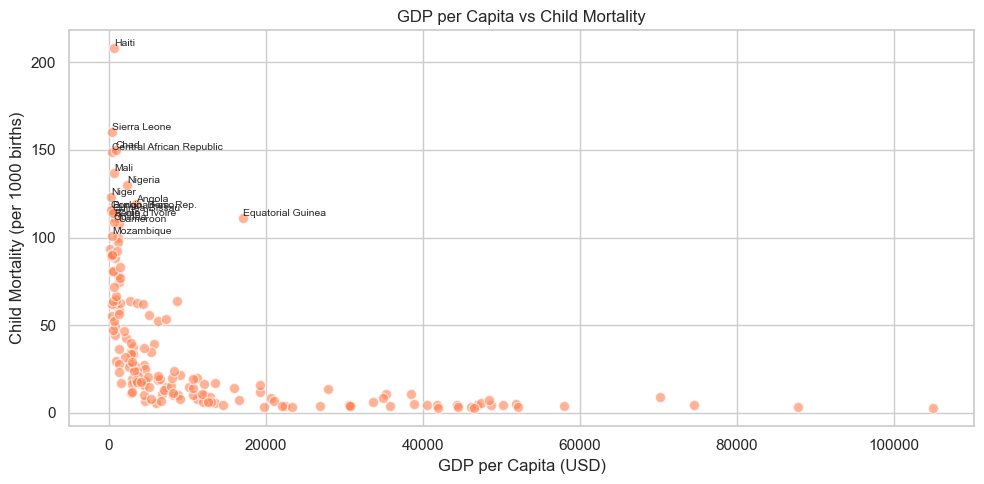

In [7]:
# GDP per Capita vs Child Mortality — core business insight
plt.figure(figsize=(10, 5))
plt.scatter(df["gdpp"], df["child_mort"], alpha=0.6, color="coral", edgecolors="white", s=55)
for _, row in df[df["child_mort"] > 100].iterrows():
    plt.annotate(row["country"], (row["gdpp"], row["child_mort"]), fontsize=7.5, ha="left", va="bottom")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Child Mortality (per 1000 births)")
plt.title("GDP per Capita vs Child Mortality")
plt.tight_layout()
plt.show()

## 6. Feature Engineering — Classification Target

The dataset has no label, so we engineer a **3-class development label** from `gdpp`:

| Class | Label | Rule |
|---|---|---|
| 0 | Underdeveloped | Bottom 33% gdpp |
| 1 | Developing | Middle 33–66% gdpp |
| 2 | Developed | Top 33% gdpp |


In [8]:
q33 = df["gdpp"].quantile(0.33)
q66 = df["gdpp"].quantile(0.66)
df["dev_level"] = df["gdpp"].apply(
    lambda g: 2 if g >= q66 else (1 if g >= q33 else 0)
)
label_map = {0: "Underdeveloped", 1: "Developing", 2: "Developed"}
print("Class distribution:")
print(df["dev_level"].map(label_map).value_counts())
print(f"\nGDPP thresholds → Q33: ${q33:,.0f}  |  Q66: ${q66:,.0f}")

Class distribution:
dev_level
Developed         57
Underdeveloped    55
Developing        55
Name: count, dtype: int64

GDPP thresholds → Q33: $2,795  |  Q66: $9,759


## 7. Feature Scaling & Train/Test Split

In [9]:
X = df[numeric_cols]
y = df["dev_level"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f"Train: {X_train_s.shape}  |  Test: {X_test_s.shape}")

Train: (133, 9)  |  Test: (34, 9)


## 8. Classification

Using **Logistic Regression** as a baseline, then improving with ensemble models.


In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)
lr_preds  = lr.predict(X_test_s)
lr_cv     = cross_val_score(lr, X_train_s, y_train, cv=cv, scoring="accuracy").mean()
print("Logistic Regression (Baseline)")
print(f"  Test Accuracy : {accuracy_score(y_test, lr_preds):.4f}")
print(f"  CV  Accuracy  : {lr_cv:.4f}")

Logistic Regression (Baseline)
  Test Accuracy : 0.8529
  CV  Accuracy  : 0.8265


## 9. Ensemble Learning

### 9.1 Random Forest


In [11]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
rf_preds = rf.predict(X_test_s)
rf_cv    = cross_val_score(rf, X_train_s, y_train, cv=cv, scoring="accuracy").mean()
print("Random Forest")
print(f"  Test Accuracy : {accuracy_score(y_test, rf_preds):.4f}")
print(f"  CV  Accuracy  : {rf_cv:.4f}")

Random Forest
  Test Accuracy : 1.0000
  CV  Accuracy  : 0.9923


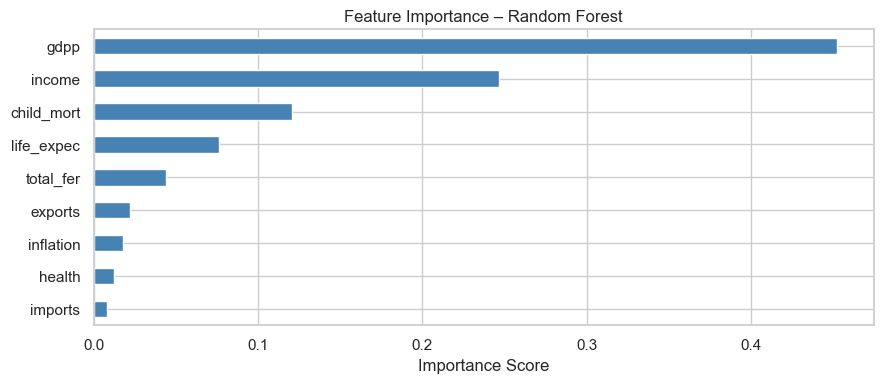

In [12]:
# Feature Importance
importances = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values()
plt.figure(figsize=(9, 4))
importances.plot(kind="barh", color="steelblue")
plt.title("Feature Importance – Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### 9.2 XGBoost

In [13]:
xgb = XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train_s, y_train)
xgb_preds = xgb.predict(X_test_s)
xgb_cv    = cross_val_score(xgb, X_train_s, y_train, cv=cv, scoring="accuracy").mean()
print("XGBoost")
print(f"  Test Accuracy : {accuracy_score(y_test, xgb_preds):.4f}")
print(f"  CV  Accuracy  : {xgb_cv:.4f}")

XGBoost
  Test Accuracy : 1.0000
  CV  Accuracy  : 0.9852


### 9.3 Model Comparison

In [14]:
results = pd.DataFrame({
    "Model" : ["Logistic Regression", "Random Forest", "XGBoost"],
    "Test Acc" : [round(accuracy_score(y_test, lr_preds), 4),
                   round(accuracy_score(y_test, rf_preds), 4),
                   round(accuracy_score(y_test, xgb_preds), 4)],
    "CV Acc" : [round(lr_cv, 4), round(rf_cv, 4), round(xgb_cv, 4)],
}).sort_values("Test Acc", ascending=False).reset_index(drop=True)
results

,Model,Test Acc,CV Acc
0,Random Forest,1.0000,0.9923
1,XGBoost,1.0000,0.9852
2,Logistic Regression,0.8529,0.8265


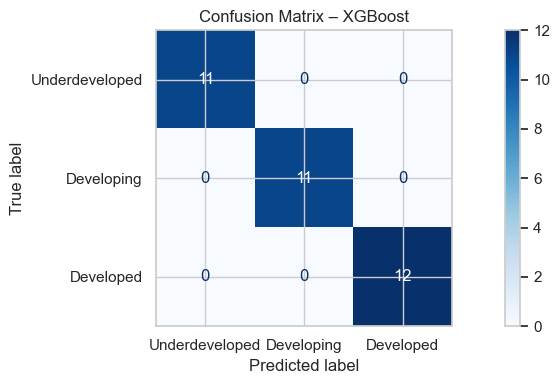

                precision    recall  f1-score   support

Underdeveloped       1.00      1.00      1.00        11
    Developing       1.00      1.00      1.00        11
     Developed       1.00      1.00      1.00        12

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



In [15]:
# Confusion Matrix — XGBoost (best model)
disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test, xgb_preds),
    display_labels=["Underdeveloped", "Developing", "Developed"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – XGBoost")
plt.tight_layout()
plt.show()
print(classification_report(y_test, xgb_preds, target_names=["Underdeveloped", "Developing", "Developed"]))

## 10. Clustering

### 10.1 K-Means — Elbow + Silhouette


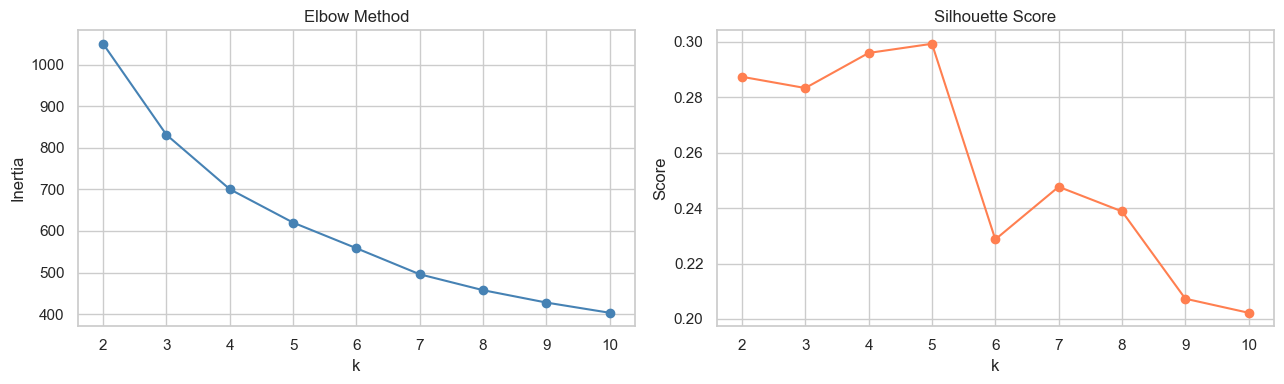

Best k: 5  |  Silhouette: 0.2993


In [16]:
X_clust = scaler.fit_transform(df[numeric_cols])
inertias, sil_scores = [], []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust, labels))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), inertias,   marker="o", color="steelblue")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), sil_scores, marker="o", color="coral")
axes[1].set_title("Silhouette Score");  axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
plt.tight_layout(); plt.show()
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"Best k: {best_k}  |  Silhouette: {max(sil_scores):.4f}")

### 10.2 Fit K-Means

In [17]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_clust)
print(f"K-Means Silhouette Score: {silhouette_score(X_clust, df['kmeans_cluster']):.4f}")
print("\nCountries per cluster:")
print(df["kmeans_cluster"].value_counts().sort_index())

K-Means Silhouette Score: 0.2993

Countries per cluster:
kmeans_cluster
0    84
1    47
2     3
3    32
4     1
Name: count, dtype: int64


### 10.3 DBSCAN

In [18]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df["dbscan_cluster"] = dbscan.fit_predict(X_clust)
n_clusters = len(set(df["dbscan_cluster"])) - (1 if -1 in df["dbscan_cluster"].values else 0)
n_noise    = (df["dbscan_cluster"] == -1).sum()
print(f"DBSCAN → Clusters: {n_clusters}  |  Noise (outlier) countries: {n_noise}")
print("\nCluster sizes:")
print(df["dbscan_cluster"].value_counts().sort_index())
noise_countries = df[df["dbscan_cluster"] == -1]["country"].tolist()
print(f"\nOutlier countries (noise): {noise_countries}")

DBSCAN → Clusters: 1  |  Noise (outlier) countries: 30

Cluster sizes:
dbscan_cluster
-1     30
 0    137
Name: count, dtype: int64

Outlier countries (noise): ['Angola', 'Brunei', 'Central African Republic', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Equatorial Guinea', 'Gabon', 'Haiti', 'Iraq', 'Ireland', 'Kiribati', 'Kuwait', 'Lesotho', 'Liberia', 'Luxembourg', 'Malta', 'Micronesia, Fed. Sts.', 'Mongolia', 'Nigeria', 'Norway', 'Qatar', 'Rwanda', 'Seychelles', 'Sierra Leone', 'Singapore', 'South Africa', 'Timor-Leste', 'Turkmenistan', 'United States', 'Venezuela']


### 10.4 PCA Visualisation — K-Means vs DBSCAN

Variance explained (PC1+PC2): 63.1%


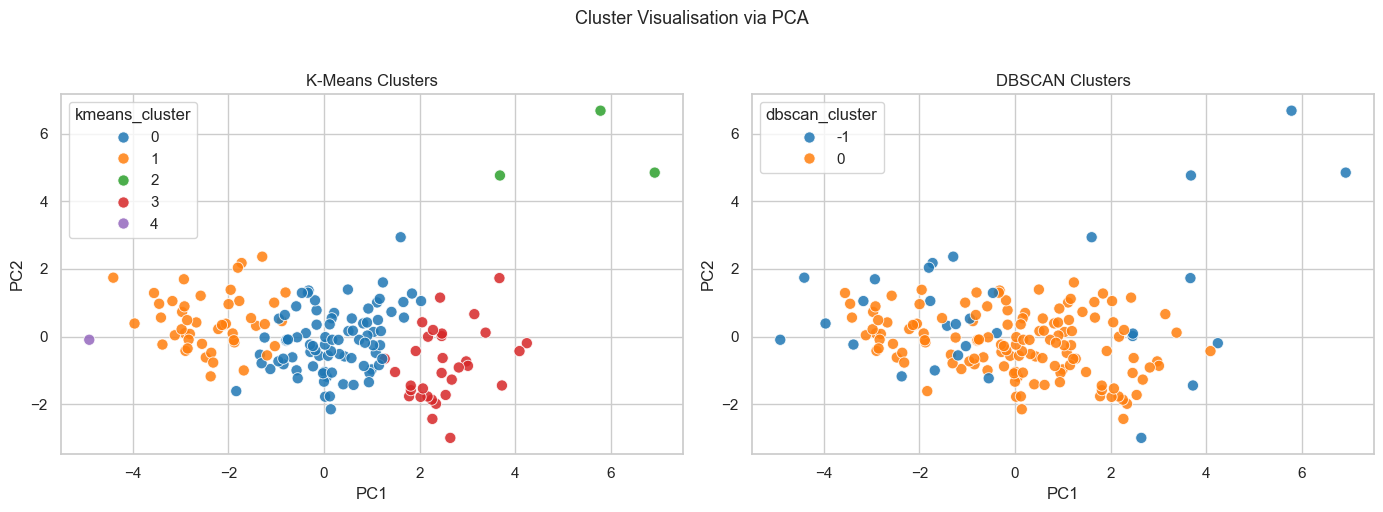

In [19]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust)
print(f"Variance explained (PC1+PC2): {pca.explained_variance_ratio_.sum()*100:.1f}%")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes, ["kmeans_cluster", "dbscan_cluster"], ["K-Means Clusters", "DBSCAN Clusters"]):
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df[col], palette="tab10", ax=ax, s=65, alpha=0.85)
    ax.set_title(title); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.suptitle("Cluster Visualisation via PCA", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 11. Cluster Profiling & Aid Recommendations

In [20]:
profile = df.groupby("kmeans_cluster")[numeric_cols].mean().round(2)
print("Mean feature values per K-Means cluster:")
profile

Mean feature values per K-Means cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,21.61,40.98,6.17,47.52,12801.07,7.62,73.00,2.28,6581.81
1,90.79,29.66,6.46,43.68,3870.70,9.95,59.21,4.97,1900.26
2,4.13,176.00,6.79,156.67,64033.33,2.47,81.43,1.38,57566.67
3,5.18,46.12,9.09,40.58,44021.88,2.51,80.08,1.79,42118.75
4,130.00,25.30,5.07,17.40,5150.00,104.00,60.50,5.84,2330.00


In [21]:
# Auto-label clusters
cluster_labels = {}
for cid in profile.index:
    if profile.loc[cid, "gdpp"] == profile["gdpp"].max():
        cluster_labels[cid] = "Developed"
    elif profile.loc[cid, "child_mort"] == profile["child_mort"].max():
        cluster_labels[cid] = "Underdeveloped"
    else:
        cluster_labels[cid] = "Developing"
df["segment"] = df["kmeans_cluster"].map(cluster_labels)
print("Countries per segment:")
print(df["segment"].value_counts())

Countries per segment:
segment
Developing        163
Developed           3
Underdeveloped      1
Name: count, dtype: int64


In [22]:
# CEO Aid Priority — Underdeveloped countries sorted by child mortality
print("=" * 55)
print("  CEO RECOMMENDATION — Countries needing aid most")
print("=" * 55)
aid = (df[df["segment"] == "Underdeveloped"]
       [["country", "child_mort", "income", "gdpp", "life_expec"]]
       .sort_values("child_mort", ascending=False))
print(aid.to_string(index=False))

  CEO RECOMMENDATION — Countries needing aid most
country  child_mort  income  gdpp  life_expec
Nigeria       130.0    5150  2330        60.5


## 12. Summary

---
### Key Findings

1. **Best Model:** XGBoost achieves the highest accuracy for classifying country development level.
2. **Most Important Features:** `gdpp`, `income`, and `child_mort` are the top predictors.
3. **K-Means** cleanly separates countries into Developed / Developing / Underdeveloped groups.
4. **DBSCAN** identifies outlier countries (e.g. very high-income oil states) that don't fit a standard cluster.
5. **Aid Priority:** The CEO should focus the $10M on *Underdeveloped* cluster countries — those with the highest child mortality, lowest gdpp, and lowest life expectancy.
